In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

from experiment_utils import (
    run_one_experiment,
    run,
    save_result,
    MLPClassifier
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("../data/Processed_Project_Data/fifa_and_elo_with_ema_v2.csv")

df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df["date"] = pd.to_datetime(df["date"], format="mixed")

df = df.sort_values("date").reset_index(drop=True)

print(df.shape)
df.head()

(1239, 49)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,...,away_form_sma7,away_form_ema50,away_form_ema33,away_form_ema25,form_diff_sma3,form_diff_sma5,form_diff_sma7,form_diff_ema50,form_diff_ema33,form_diff_ema25
0,2022-01-27,Jamaica,Mexico,1.0,2.0,FIFA World Cup qualification,Kingston,Jamaica,0,2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-27,United Arab Emirates,Syria,2.0,0.0,FIFA World Cup qualification,Dubai,United Arab Emirates,0,2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-01-27,Honduras,Canada,0.0,2.0,FIFA World Cup qualification,San Pedro Sula,Honduras,0,2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-01-27,Costa Rica,Panama,1.0,0.0,FIFA World Cup qualification,San José,Costa Rica,0,2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-01-27,Lebanon,South Korea,0.0,1.0,FIFA World Cup qualification,Sidon,Lebanon,0,2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
features = [
    "home_form_sma3",
    "away_form_sma3"
]

target = "result"

In [5]:
df = df.dropna(subset=features + [target]).reset_index(drop=True)

print(df.shape)
df[features + [target]].head()

(1110, 49)


,home_form_sma3,away_form_sma3,result
0,3.0,3.0,0
1,3.0,3.0,1
2,0.0,0.0,-1
3,0.0,0.0,1
4,3.0,3.0,1


In [6]:
X = df[features].values
y_raw = df[target].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

print("Label encoding:")
for original_label, encoded_label in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(f"{original_label} -> {encoded_label}")

Label encoding:
-1 -> 0
0 -> 1
1 -> 2


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(888, 2)
(222, 2)
(888,)
(222,)


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

print(X_train_tensor.shape)
print(y_train_tensor.shape)
print(X_test_tensor.shape)
print(y_test_tensor.shape)

torch.Size([888, 2])
torch.Size([888])
torch.Size([222, 2])
torch.Size([222])


In [10]:
import random

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

input_dim = X_train_tensor.shape[1]

model = MLPClassifier(input_dim=input_dim)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Epoch 50/1000 | train loss = 1.0132 | val loss = 0.9905 | val acc = 0.5562
Epoch 100/1000 | train loss = 1.0168 | val loss = 0.9940 | val acc = 0.5618
Epoch 150/1000 | train loss = 1.0095 | val loss = 0.9911 | val acc = 0.5562
Epoch 200/1000 | train loss = 1.0162 | val loss = 0.9961 | val acc = 0.5506
Epoch 250/1000 | train loss = 1.0143 | val loss = 0.9946 | val acc = 0.5562
Epoch 300/1000 | train loss = 1.0060 | val loss = 0.9957 | val acc = 0.5506
Epoch 350/1000 | train loss = 1.0092 | val loss = 0.9955 | val acc = 0.5562
Epoch 400/1000 | train loss = 1.0119 | val loss = 0.9992 | val acc = 0.5281
Epoch 450/1000 | train loss = 1.0008 | val loss = 0.9970 | val acc = 0.5225
Epoch 500/1000 | train loss = 1.0087 | val loss = 0.9971 | val acc = 0.5225
Epoch 550/1000 | train loss = 0.9932 | val loss = 0.9971 | val acc = 0.5225
Epoch 600/1000 | train loss = 0.9876 | val loss = 0.9946 | val acc = 0.5225
Epoch 650/1000 | train loss = 0.9976 | val loss = 0.9958 | val acc = 0.5225
Epoch 700/100

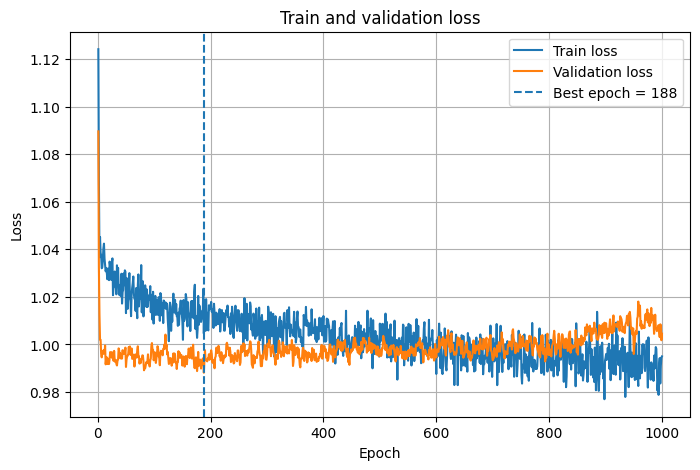

0.6171171171171171

In [11]:
run_one_experiment(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
)

In [12]:
best_num_epochs = 188

summary, results_df = run(
    model_class=MLPClassifier,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
    num_epochs=best_num_epochs,
)

Run 1/10
Accuracy: 0.6171 | Precision: 0.4078 | Recall: 0.4907 | Specificity: 0.7675 | F1: 0.4395

Run 2/10
Accuracy: 0.6171 | Precision: 0.4085 | Recall: 0.4886 | Specificity: 0.7666 | F1: 0.4379

Run 3/10
Accuracy: 0.6126 | Precision: 0.4064 | Recall: 0.4855 | Specificity: 0.7637 | F1: 0.4354

Run 4/10
Accuracy: 0.6126 | Precision: 0.4043 | Recall: 0.4855 | Specificity: 0.7645 | F1: 0.4348

Run 5/10
Accuracy: 0.6081 | Precision: 0.4036 | Recall: 0.4783 | Specificity: 0.7598 | F1: 0.4288

Run 6/10
Accuracy: 0.6171 | Precision: 0.4132 | Recall: 0.4886 | Specificity: 0.7649 | F1: 0.4392

Run 7/10
Accuracy: 0.6171 | Precision: 0.4054 | Recall: 0.4928 | Specificity: 0.7692 | F1: 0.4405

Run 8/10
Accuracy: 0.6171 | Precision: 0.4132 | Recall: 0.4886 | Specificity: 0.7649 | F1: 0.4392

Run 9/10
Accuracy: 0.6171 | Precision: 0.4132 | Recall: 0.4886 | Specificity: 0.7649 | F1: 0.4392

Run 10/10
Accuracy: 0.6081 | Precision: 0.4036 | Recall: 0.4783 | Specificity: 0.7598 | F1: 0.4288

Summary o

In [13]:
save_result(
    experiment_name="Experiment_2-1_v2_points_SMA3",
    summary=summary
)


Saved result for Experiment_2-1_v2_points_SMA3
File: ../results/experiment_summary_final.csv
